# 01 — Classical GAN Baseline (SMI log-returns)

**ZHAW CEC Quantum Computing — Final project**

This notebook trains a small classical GAN on Swiss Market Index log-return windows and saves results to `results/classical/` for later head-to-head comparison with the hybrid quantum GAN.

All heavy lifting lives in `src/` so this notebook stays short.

## Setup (Colab)

Skip cells with `# colab-only` if running locally.

In [2]:
!pip install -q yfinance pennylane

In [6]:
# colab-only: clone repo & install deps. Comment out when running locally.
!git clone https://github.com/wuns/qGAN-market-generator.git
%cd qGAN-market-generator
!pip install -q -r requirements.txt

Cloning into 'qGAN-market-generator'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 2), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 12.67 KiB | 4.22 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/qGAN-market-generator
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.9 MB/s eta 0:00:00


In [7]:
!pwd
!ls

/content/qGAN-market-generator
notebooks  README.md  requirements.txt	results  src


In [9]:
import numpy
print('numpy version:', numpy.__version__)
print('numpy file:', numpy.__file__)

numpy version: 2.0.2
numpy file: /usr/local/lib/python3.12/dist-packages/numpy/__init__.py


In [10]:
import sys, pathlib, json
# Make src/ importable whether running locally from notebooks/ or from Colab root.
ROOT = pathlib.Path.cwd()
if (ROOT / 'src').is_dir():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'src').is_dir():
    sys.path.insert(0, str(ROOT.parent))
    ROOT = ROOT.parent

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data       import prepare_smi_data
from src.models     import ClassicalGenerator, Discriminator, count_parameters
from src.training   import set_seed, make_dataloader, train_gan, generate
from src.evaluation import (summarise, ks_distance, plot_distributions,
                            plot_acf_comparison, plot_sample_paths, build_report)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device, '| repo root =', ROOT)

device = cpu | repo root = /content/qGAN-market-generator


## Config

In [11]:
SEED       = 42
WINDOW     = 20
LATENT_DIM = 8
EPOCHS     = 80
BATCH      = 64

set_seed(SEED)

## Data

Train windows: (3996, 20)
Test  windows: (985, 20)
Scale (4 sigma): 0.04209


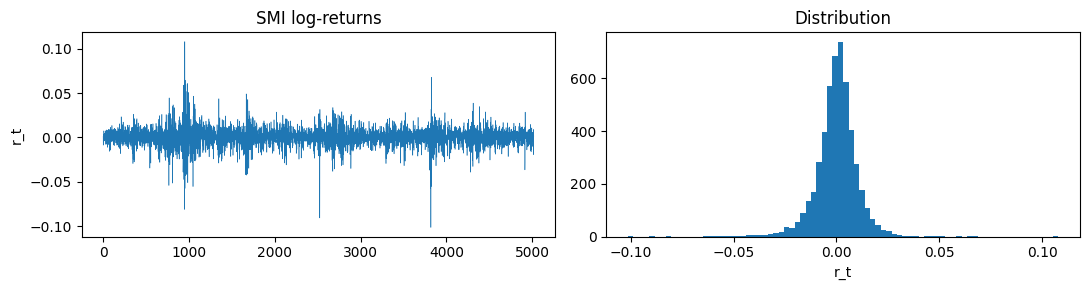

In [12]:
data = prepare_smi_data(
    window=WINDOW,
    cache_path=ROOT / 'results' / 'smi_prices.pkl',  # speeds up repeat runs
)
print(f'Train windows: {data.train_windows.shape}')
print(f'Test  windows: {data.test_windows.shape}')
print(f'Scale (4 sigma): {data.scale:.5f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(data.raw_returns, lw=0.4); ax[0].set_title('SMI log-returns'); ax[0].set_ylabel('r_t')
ax[1].hist(data.raw_returns, bins=80); ax[1].set_title('Distribution'); ax[1].set_xlabel('r_t')
plt.tight_layout(); plt.show()

## Model & training

In [13]:
G = ClassicalGenerator(latent_dim=LATENT_DIM, window=WINDOW)
D = Discriminator(window=WINDOW)
n_params_G = count_parameters(G)
n_params_D = count_parameters(D)
print(f'Generator params:     {n_params_G}')
print(f'Discriminator params: {n_params_D}')

loader = make_dataloader(data.train_windows, batch_size=BATCH)
history = train_gan(G, D, loader, latent_dim=LATENT_DIM, epochs=EPOCHS, device=device)
print(f'\nTraining time: {history.train_time_sec:.1f} s')

Generator params:     2004
Discriminator params: 3457
  epoch  10/80  D=1.367  G=0.718
  epoch  20/80  D=1.426  G=0.692
  epoch  30/80  D=1.369  G=0.754
  epoch  40/80  D=1.381  G=0.699
  epoch  50/80  D=1.424  G=0.678
  epoch  60/80  D=1.377  G=0.712
  epoch  70/80  D=1.330  G=0.708
  epoch  80/80  D=1.375  G=0.704

Training time: 19.1 s


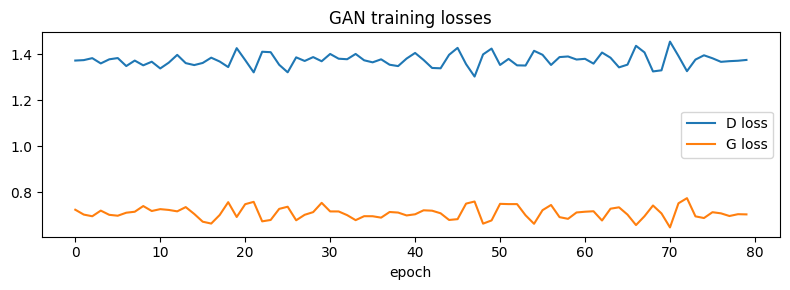

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(history.d_loss, label='D loss')
plt.plot(history.g_loss, label='G loss')
plt.xlabel('epoch'); plt.legend(); plt.title('GAN training losses')
plt.tight_layout(); plt.show()

For a GAN trained with BCEWithLogitsLoss, two reference values matter:

*   ln(2) ≈ 0.693 — the loss when the discriminator outputs 50/50, i.e. when D can no longer tell real from fake. This is the theoretical equilibrium of a perfectly trained GAN.
*   2 × ln(2) ≈ 1.386 — the same equilibrium for the discriminator's loss, because D's loss sums the real and fake terms.




## Generate & evaluate

In [15]:
n_eval = len(data.test_windows)
fake_scaled, t_inf = generate(G, n_eval, LATENT_DIM, device=device)
fake_returns = data.unscale(fake_scaled)
real_returns = data.unscale(data.test_windows)
samples_per_sec = (n_eval * WINDOW) / t_inf
print(f'Inference: {n_eval} windows in {t_inf*1000:.1f} ms ({samples_per_sec:.0f} samples/s)')

Inference: 985 windows in 2.2 ms (9064040 samples/s)


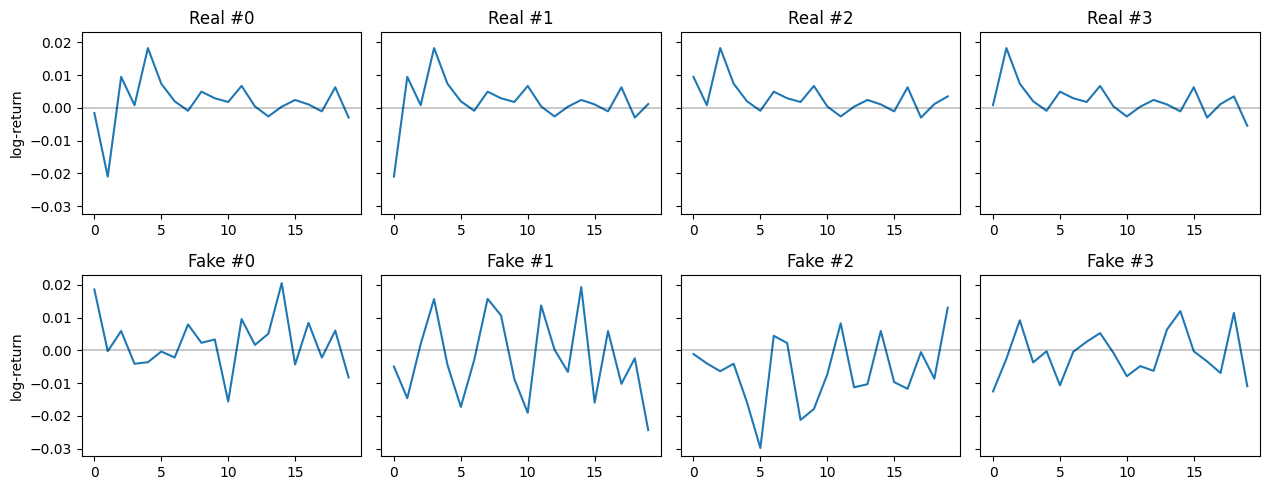

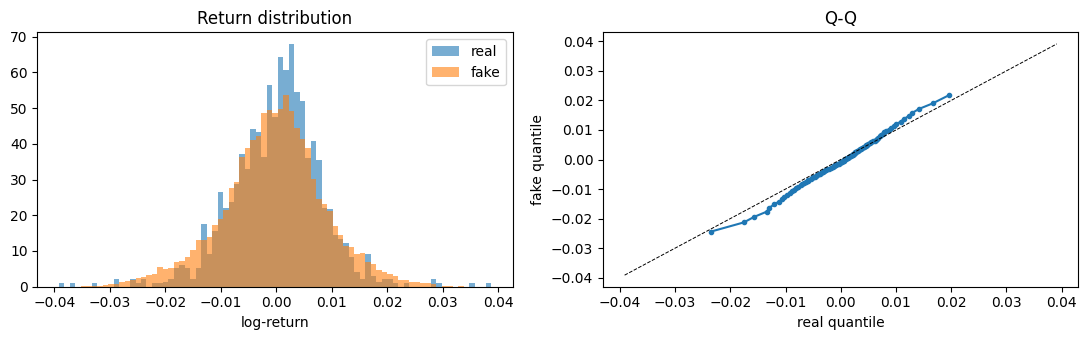

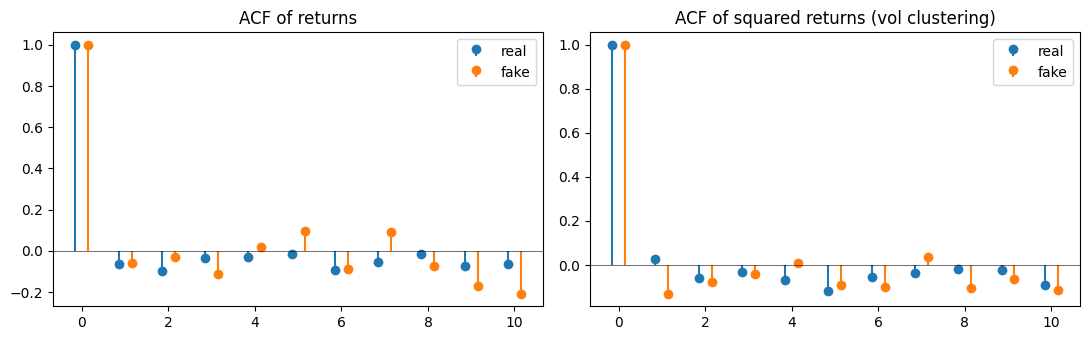

In [16]:
plot_sample_paths(real_returns, fake_returns); plt.tight_layout(); plt.show()
plot_distributions(real_returns, fake_returns); plt.tight_layout(); plt.show()
plot_acf_comparison(real_returns, fake_returns); plt.tight_layout(); plt.show()

In [17]:
report = build_report(
    real_returns=real_returns,
    fake_returns=fake_returns,
    n_params_G=n_params_G,
    n_params_D=n_params_D,
    train_time_sec=history.train_time_sec,
    inference_samples_per_sec=samples_per_sec,
    extras={'seed': SEED, 'epochs': EPOCHS, 'window': WINDOW, 'latent_dim': LATENT_DIM,
            'model': 'classical_mlp_gan'},
)
for k, v in report.items():
    print(f'{k:30s} {v}')

real_summary                   {'name': 'real', 'n': 19700, 'mean': 8.777576294960454e-05, 'std': 0.008086292073130608, 'skew': -0.2134746015071869, 'kurtosis': 2.352694034576416, 'minimum': -0.039138831198215485, 'maximum': 0.0387004092335701}
fake_summary                   {'name': 'fake', 'n': 19700, 'mean': -0.00042955626850016415, 'std': 0.009148395620286465, 'skew': -0.13965414464473724, 'kurtosis': 0.5794920921325684, 'minimum': -0.03509892523288727, 'maximum': 0.03303557261824608}
ks_statistic                   0.05584
ks_pvalue                      3.908385644601546e-27
n_params_generator             2004
n_params_discriminator         3457
training_time_sec              19.08
inference_samples_per_sec      9064040.0
seed                           42
epochs                         80
window                         20
latent_dim                     8
model                          classical_mlp_gan


## Save artefacts

These will be loaded by `03_comparison.ipynb`.

In [18]:
out = ROOT / 'results' / 'classical'; out.mkdir(parents=True, exist_ok=True)
torch.save(G.state_dict(), out / 'generator.pt')
np.save(out / 'fake_returns.npy', fake_returns)
np.save(out / 'real_returns_test.npy', real_returns)
np.save(out / 'scale.npy', np.array([data.scale]))
with open(out / 'metrics.json', 'w') as f:
    json.dump(report, f, indent=2, default=float)
print('Saved to', out)

Saved to /content/qGAN-market-generator/results/classical


## Next

Notebook `02_quantum_gan.ipynb` will reuse the same `Discriminator`, `train_gan`, and evaluation functions, replacing only the generator with a small variational quantum circuit.